In [30]:
import os
import re
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import partial_r as pr
from pathlib import Path
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import regression_functions as rf
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from matplotlib.backends.backend_pdf import PdfPages
from figure_formatting import setup_figure, save_figure
from sklearn.model_selection import KFold, RepeatedKFold
from regression_functions import run_model_comparison as run_model
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score

importlib.reload(rf)
importlib.reload(pr)

<module 'partial_r' from '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/code/partial_r.py'>

In [31]:
import logging
import matplotlib as mpl

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Liberation Sans"]

### Load in data

In [32]:
# output of Figure_6_HBN_harmonization.Rmd
# ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
ROOT_DIR = Path("/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome")
HARMONIZED_DIR = ROOT_DIR / "output_data" / "harmonized" / "HBN"

df_HBN = pd.read_csv(HARMONIZED_DIR / "HBN_harmonized_refABCD16_then_nuisanceResid_12_23.csv")

print(df_HBN.shape)
df_HBN.head(3)

(869, 1311)


,participant_id,site,batch,dataset,age,sex,qc_prediction,General_SES,matched_group,bundle_Association_ArcuateFasciculusL_1st_quarter_volume_mm3,...,bundle_ProjectionBrainstem_ReticularTractR_mean_length_mm,bundle_ProjectionBrainstem_ReticularTractR_radius_of_end_region_1_mm,bundle_ProjectionBrainstem_ReticularTractR_radius_of_end_region_2_mm,bundle_ProjectionBrainstem_ReticularTractR_span_mm,bundle_ProjectionBrainstem_ReticularTractR_total_area_of_end_regions_mm2,bundle_ProjectionBrainstem_ReticularTractR_total_radius_of_end_regions_mm,bundle_ProjectionBrainstem_ReticularTractR_total_surface_area_mm2,bundle_ProjectionBrainstem_ReticularTractR_total_volume_mm3,bundle_ProjectionBrainstem_ReticularTractR_volume_of_end_branches_1,bundle_ProjectionBrainstem_ReticularTractR_volume_of_end_branches_2
0,sub-NDARAA504CRN,cbic,HBN_cbic,HBN,9.165297,1,0.982532,-0.12,NaN,-492.148709,...,-2.629507,-0.923701,5.129568,-1.403014,-407.473896,3.780532,-3470.483915,-2087.162508,-163.378356,-163.378356
1,sub-NDARAB282FDJ,cuny,HBN_cuny,HBN,11.500570,1,0.981161,0.63,NaN,556.804749,...,2.882304,0.765540,0.947294,2.696575,922.080055,1.156604,2123.503447,2867.791498,706.050366,706.050366
2,sub-NDARAB514MAJ,cbic,HBN_cbic,HBN,5.055213,0,0.980201,0.92,NaN,2578.879681,...,0.861895,-0.499412,-1.896670,0.785526,-501.884639,-2.394061,-3245.140905,-1605.362958,364.853002,364.853002


In [33]:
df_HBN["participant_id"].nunique()

869

In [34]:
df_HBN['age'].min(), df_HBN['age'].max()

(np.float64(5.055213), np.float64(21.384325))

In [35]:
RESULTS_DIR = ROOT_DIR / "output_data" / "results"

dfA_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_12_10.csv")
dfB_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_12_10.csv")

### Multivariate Ridge Regression

In [36]:
features_macro_noddi = [c for c in dfA_macro_plus_NODDI.columns if c.startswith("bundle_")]
msmt_cols = [f for f in features_macro_noddi if f in df_HBN.columns]

In [37]:
FIG6_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure6"
FIG6_DIR.mkdir(parents=True, exist_ok=True)

target = "General_SES"
confounds = ['age', 'sex', "t1post_dwi_contrast"]
model_type = 'ridge'

train_A = dfA_macro_plus_NODDI[dfA_macro_plus_NODDI["matched_group"] == 1].copy()
train_B = dfB_macro_plus_NODDI[dfB_macro_plus_NODDI["matched_group"] == 2].copy()

# train on abcd split half A, test on HBN
res_A = rf.train_and_test_external(df_train=train_A, df_ext=df_HBN, features_subset=msmt_cols, confounds=confounds,
                                   target=target, label="ABCD_A_to_HBN_macroNODDI", output_dir=FIG6_DIR,
                                   test_features_already_residualized=True, model_type=model_type)

# train on abcd split half B, test on HBN
res_B = rf.train_and_test_external(df_train=train_B, df_ext=df_HBN, features_subset=msmt_cols, confounds=confounds,
                                   target=target, label="ABCD_A_to_HBN_macroNODDI", output_dir=FIG6_DIR,
                                   test_features_already_residualized=True, model_type=model_type)

print(f"Train on df_A, test on HBN: r = {res_A['r']:.3f}, r2 = {res_A['r2']:.3f}")
print(f"Train on df_B, test on HBN: r = {res_B['r']:.3f}, r2 = {res_B['r2']:.3f}")

Train on df_A, test on HBN: r = 0.316, r2 = -1.614
Train on df_B, test on HBN: r = 0.332, r2 = -1.667


[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure6/MacroNODDI_ABCD_to_HBN_scatter_clean.svg
[SAVE] → /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/main_figures/figure6/MacroNODDI_ABCD_to_HBN_scatter_clean.png


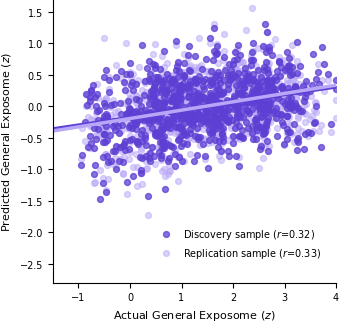

In [38]:
y_true = res_A["y_true"]  # HBN true values
y_pred_A = res_A["y_pred"]  # preds from discovery sample
y_pred_B = res_B["y_pred"]  # preds from replication sample

r_A, _ = pearsonr(y_true, y_pred_A)
r_B, _ = pearsonr(y_true, y_pred_B)

fig, ax = setup_figure(width_mm=90, height_mm=90, base_pt=7, label_pt=8, title_pt=9, margins_mm=(12, 6, 10, 8))

ax.set_xlim(-1.5, 4)
ax.set_ylim(-2.8, 1.7)
x_grid = np.linspace(-1.5, 4, 200)

color_disc = "#5D3FD3"
color_rep = "#B8A6F9"

# scatter (plot replication first, then discovery so discovery is on top)
sc_rep = ax.scatter(y_true, y_pred_B, alpha=0.5, s=18, marker="o", color=color_rep,
                    label=rf"Replication sample ($r$={r_B:.2f})", zorder=1)
sc_disc = ax.scatter(y_true, y_pred_A, alpha=0.75, s=18, marker="o", color=color_disc,
                     label=rf"Discovery sample ($r$={r_A:.2f})", zorder=2)

# regression lines
m_A, b_A = np.polyfit(y_true, y_pred_A, 1)
ax.plot(x_grid, m_A * x_grid + b_A, color=color_disc, lw=2.5)

m_B, b_B = np.polyfit(y_true, y_pred_B, 1)
ax.plot(x_grid, m_B * x_grid + b_B, color=color_rep, lw=2.5)

# labels
ax.set_xlabel(r"Actual General Exposome ($z$)")
ax.set_ylabel(r"Predicted General Exposome ($z$)")

# legend (force order)
handles, labels = ax.get_legend_handles_labels()
lab_A = rf"Discovery sample ($r$={r_A:.2f})"
lab_B = rf"Replication sample ($r$={r_B:.2f})"
order = [labels.index(lab_A), labels.index(lab_B)]
ax.legend([handles[i] for i in order], [labels[i] for i in order],
          frameon=False, loc="lower right", bbox_to_anchor=(0.98, 0.05))

sns.despine(ax=ax, top=True, right=True)

svg_path = FIG6_DIR / "MacroNODDI_ABCD_to_HBN_scatter_clean.svg"
png_path = FIG6_DIR / "MacroNODDI_ABCD_to_HBN_scatter_clean.png"

save_figure(fig, svg_path, autofit=False)
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"[SAVE] → {svg_path}")
print(f"[SAVE] → {png_path}")

plt.show()

### Permutation test for multivariate regression

In [39]:
def prepare_external_data_no_nuisance(df_train, df_ext, features_subset, target):
    shared_features = [f for f in features_subset if f in df_train.columns and f in df_ext.columns]

    # Features
    X_train = df_train[shared_features].values
    X_ext   = df_ext[shared_features].values

    # Targets
    y_train = df_train[[target]].values
    y_ext   = df_ext[[target]].values

    # Standardize X (train only)
    X_scaler = StandardScaler().fit(X_train)
    X_train_std = X_scaler.transform(X_train)
    X_ext_std   = X_scaler.transform(X_ext)

    # Standardize y (train only), then flatten to 1D
    y_scaler = StandardScaler().fit(y_train)
    y_train_std = y_scaler.transform(y_train).reshape(-1)
    y_ext_std   = y_scaler.transform(y_ext).reshape(-1)

    return X_train_std, y_train_std, X_ext_std, y_ext_std, shared_features

def permutation_test_external_no_nuisance(df_train, df_ext, features_subset, target, model_type="ridge", n_permutations=1000):

    X_train_std, y_train_std, X_ext_std, y_ext_std, shared_features = prepare_external_data_no_nuisance(df_train=df_train, df_ext=df_ext, 
                                                                                                        features_subset=features_subset,
                                                                                                        target=target)

    r_true, null_dist, p_val = rf.permutation_test(X_train=X_train_std, y_train=y_train_std, X_test=X_ext_std,  y_test=y_ext_std,
                                                   n_permutations=n_permutations, model_type=model_type)
    return r_true, null_dist, p_val, shared_features


In [ ]:
perm_dir = FIG6_DIR / "permutation_results"
perm_dir.mkdir(parents=True, exist_ok=True)

n_perm = 1000

# ABCD A → HBN permutations
print("Running permutations: ABCD A → HBN")
r_true_A, null_A, p_A, _ = rf.permutation_test_external(df_train=train_A, df_ext=df_HBN, features_subset=msmt_cols,
                                                       target=target, model_type=model_type, n_permutations=n_perm)

np.savez(perm_dir / "ABCD_A_to_HBN_macroNODDI_perm.npz",
         r_true=r_true_A, null=null_A, p_val=p_A)

# ABCD B → HBN permutations
print("Running permutations: ABCD B → HBN")
r_true_B, null_B, p_B, _ = rf.permutation_test_external(df_train=train_B, df_ext=df_HBN, features_subset=msmt_cols,
                                                       target=target, model_type=model_type, n_permutations=n_perm)

np.savez(perm_dir / "ABCD_B_to_HBN_macroNODDI_perm.npz",
         r_true=r_true_B, null=null_B, p_val=p_B)

print(f"Perm ABCD A→HBN: r_true={r_true_A:.3f}, p={p_A:.3g}")
print(f"Perm ABCD B→HBN: r_true={r_true_B:.3f}, p={p_B:.3g}")

Running permutations: ABCD A → HBN


### Mass Univariate Regression

In [ ]:
def parse_feature_name_msmt(feat):
    rest = feat.replace("bundle_", "", 1)
    parts = rest.split("_")
    bundle = "_".join(parts[:2])     # bundle always has exactly one underscore
    metric = "_".join(parts[2:])     # metric is everything else
    return bundle, metric

def add_bundle_metric_cols(df):
    bundles, metrics = zip(*df["feature"].map(parse_feature_name_msmt))
    return df.assign(bundle=bundles, metric=pd.Series(metrics, index=df.index).str.lower())

def percentile_limits(x, y, buffer=0.1, pad=0.05):
    xmin, xmax = np.percentile(np.asarray(x), [buffer, 100-buffer])
    ymin, ymax = np.percentile(np.asarray(y), [buffer, 100-buffer])
    xr, yr = xmax - xmin, ymax - ymin
    return (xmin - pad*xr, xmax + pad*xr, ymin - pad*yr, ymax + pad*yr)

def plot_single_scatter(ax, feat, dfH, dfH_r):
    bundle, metric = parse_feature_name_msmt(feat)
    clean_bundle = pr.clean_bundle_name_noLR(bundle) if hasattr(pr, "clean_bundle_name_noLR") else bundle
    metric_label = fixed_labels.get(metric, metric)
    y_label = f"{clean_bundle} — {metric_label}"

    x = dfH[target].values
    y = dfH[feat].values

    rH = dfH_r.loc[dfH_r["feature"] == feat, "partial_r"].iat[0]

    ax.scatter(x, y, color=disc_color, alpha=alpha, s=14, marker="o")
    xmin, xmax, ymin, ymax = percentile_limits(x, y)

    slope, intercept = np.polyfit(x, y, 1)
    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, slope*xx + intercept, color=disc_color, lw=3, alpha=1)

    ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax))
    ax.set_xlabel("General Exposome", fontsize=label_size)
    ax.set_ylabel(y_label, fontsize=label_size)
    ax.tick_params(labelsize=tick_size)

    ax.text(xmin + 0.05*(xmax-xmin), ymax - 0.1*(ymax-ymin), f"partial r={rH:.2f}",
            fontsize=label_size, ha="left", va="top",
            bbox=dict(facecolor="white", edgecolor="white", lw=0.8, alpha=0.85, boxstyle="round,pad=0.3"))

    sns.despine(ax=ax, top=True, right=True)

In [ ]:
def clean_metrics_name(name):
    name = name.replace('_', ' ') # underscores → spaces
    name = re.sub(r'\s*mm[23]?\s*$', '', name, flags=re.IGNORECASE)
    name = name.strip()

    if name.upper().startswith("NODDI") or name.upper().startswith("DKI"):
        parts = name.split()
        parts = [p.upper() for p in parts]
        return " ".join(parts)

    ordinal_allowed = ("quarter" in name.lower())

    def ordinalize(s):
        s = s.lower()
        if s.isdigit():
            n = int(s)
            if n % 10 == 1: return f"{n}st"
            elif n % 10 == 2: return f"{n}nd"
            elif n % 10 == 3: return f"{n}rd"
            else: return f"{n}th"
        return s

    stopwords = {"of", "and", "in", "for", "to", "with", "on", "at"}
    words = name.split()

    cleaned_words = []
    for w in words:
        if w.isdigit():
            if ordinal_allowed: cleaned_words.append(ordinalize(w))
            else: cleaned_words.append(w)  # keep plain number
        elif w.lower() in stopwords: cleaned_words.append(w.lower())
        else: cleaned_words.append(w.capitalize())
    return " ".join(cleaned_words) 

def clean_bundle_name(name):
    for p in prefixes:
        if name.startswith(p):
            name = name[len(p):] # removes prefix
            break
    name = re.sub(r'(?<!^)(?=[A-Z])', ' ', name) # adds space between each word
    return name.strip()

In [ ]:
HARMONIZED_DIR = ROOT_DIR / "output_data" / "harmonized" / "HBN"
FIG6_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure6"

dfH = pd.read_csv(HARMONIZED_DIR / "HBN_harmonized_refABCD16_01_20.csv")  # for scatters
dfH_r = pd.read_csv(FIG6_DIR / "HBN_SES_partial_gam_results.csv")

In [ ]:
# --- helper to extract metric name from cleaned columns ---
def extract_metric_name(col):
    if not col.startswith("bundle_"):
        return None

    parts = col[len("bundle_"):].split("_")
    if len(parts) < 3: return None

    # first two parts are the bundle name, rest is the metric
    return "_".join(parts[2:])


# --- metric summaries after cleaning ---
noddi_macro_metrics = sorted({m for c in dfA_macro_plus_NODDI.columns if (m := extract_metric_name(c)) is not None})

noddi_macro_metrics_dict = {m: clean_metrics_name(m) for m in noddi_macro_metrics}

# list of tracts
tracts = sorted(set(
    "_".join(c.split("_")[1:3])
    for c in dfA_macro_plus_NODDI.columns
    if c.startswith("bundle_")))

prefixes = ['Association_', 'Cerebellum_', 'Commissure_', 'ProjectionBrainstem_', 'ProjectionBasalGanglia_']

tract_dict = {t: clean_bundle_name(t) for t in tracts}
print(len(tract_dict))

In [ ]:
target = "General_SES"
covariates = ["General_SES", "age", "sex", "qc_prediction"]

In [ ]:
FIG6_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure6"
FIG6_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = setup_figure(width_mm=180, height_mm=130, margins_mm=(40, 2, 18, 6))
cmap = sns.diverging_palette(250, 15, s=95, l=55, as_cmap=True)

vals = dfH_r["partial_r"].to_numpy()
finite_vals = vals[np.isfinite(vals)]
vmax = np.nanpercentile(np.abs(finite_vals), 98)
if vmax == 0:
    vmax = 1.0
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

palette_bundle = {
  "Association_"          : "#4E79A7",
  "ProjectionBrainstem_"  : "#F28E2B",
  "ProjectionBasalGanglia_" : "#59A14F",
  "Cerebellum_"           : "#E15759",
  "Commissure_"           : "#B07AA1"
}

pr.make_partial_r_heatmap_with_fdr_stars(
    df=dfH_r,
    covariate=target,
    ax=ax,
    cmap=cmap,
    norm=norm,
    noddi_macro_metrics_dict=noddi_macro_metrics_dict,
    bundle_palette=palette_bundle
)

pdf_path = FIG6_DIR / "heatmap_HBN_SES_partialr_FDRstars.pdf"
png_path = FIG6_DIR / "heatmap_HBN_SES_partialr_FDRstars.png"

save_figure(fig, pdf_path, autofit=False)
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"[SAVE] -> {pdf_path}")
print(f"[SAVE] -> {png_path}")

plt.show()

In [ ]:
FIG6_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure6"

dfAB = pd.read_csv(FIG6_DIR / "abcd_partialr_avg.csv")

h = dfH_r.groupby("feature", as_index=False)["partial_r"].mean().rename(columns={"partial_r": "partial_r_H"})
abcd_h = dfAB.merge(h, on="feature", how="inner").dropna(subset=["partial_r_avg", "partial_r_H"])

print(abcd_h.shape)
abcd_h.head()

In [ ]:
fig, ax = setup_figure(width_mm=100, height_mm=100, margins_mm=(20, 0, 20, 6))

disc_color, repl_color = "#0033A0", "#7BA6E6"
alpha = 0.6

x = abcd_h["partial_r_avg"].to_numpy()
y = abcd_h["partial_r_H"].to_numpy()
r_concord = np.corrcoef(x, y)[0, 1]

ax.scatter(x, y, s=12, color=repl_color, alpha=alpha, edgecolor="none")

lo = np.nanmin([x.min(), y.min()])
hi = np.nanmax([x.max(), y.max()])

pad = 0.05 * (hi - lo)
lo -= pad
hi += pad

slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(lo, hi, 300)
ax.plot(xs, slope * xs + intercept, color=disc_color, lw=2)

ax.text(0.05, 0.95, f"r = {r_concord:.2f}", fontsize=10, transform=ax.transAxes, ha="left", va="top")

ax.set_xlabel("ABCD Partial r")
ax.set_ylabel("HBN Partial r")

sns.despine(ax=ax)

save_figure(fig, FIG6_DIR / "concordance_ABCDavg_vs_HBN.svg", autofit=False)
plt.show()

In [ ]:
output_dir = FIG6_DIR

fig, axes = setup_figure(
    width_mm=150, height_mm=80,
    margins_mm=(12, 6, 12, 8),
    nrows=1, ncols=2
)
ax_pr, ax_pred = axes
fig.subplots_adjust(wspace=0.30)

# ====================================================
# Color scheme
# ====================================================
# Univariate (LEFT) → blue family
blue_pts  = "#7BA6E6"
blue_line = "#0033A0"

# Multivariate (RIGHT) → softened purple family
purple_pts_disc = "#8B7FD6"   # discovery
purple_pts_rep  = "#C7BFF0"   # replication
purple_line     = "#5E4FB2"

# ====================================================
# Panel A: Partial-r concordance (HBN vs ABCD)
# ====================================================
alpha = 0.55

x = abcd_h["partial_r_H"].to_numpy()
y = abcd_h["partial_r_avg"].to_numpy()
r_concord = np.corrcoef(x, y)[0, 1]

ax_pr.scatter(x, y, s=12, color=blue_pts, alpha=alpha, edgecolor="none")

# regression
slope, intercept = np.polyfit(x, y, 1)

x0, x1 = np.nanpercentile(x, [1, 99])
y0, y1 = np.nanpercentile(y, [1, 99])
xpad = 0.08 * (x1 - x0) if x1 > x0 else 0.01
ypad = 0.08 * (y1 - y0) if y1 > y0 else 0.01

ax_pr.set_xlim(float(x0 - xpad), float(x1 + xpad))
ax_pr.set_ylim(float(y0 - ypad), float(y1 + ypad))

xs = np.linspace(ax_pr.get_xlim()[0], ax_pr.get_xlim()[1], 300)
ax_pr.plot(xs, slope * xs + intercept, color=blue_line, lw=2.5)

ax_pr.text(
    0.05, 0.95, rf"$\mathit{{r}} = {r_concord:.2f}$",
    fontsize=7, transform=ax_pr.transAxes,
    ha="left", va="top"
)

ax_pr.set_xlabel("HBN Partial $r$")
ax_pr.set_ylabel("ABCD Partial $r$")

sns.despine(ax=ax_pr, top=True, right=True)

# ====================================================
# Panel B: Predicted vs Actual (Multivariate)
# ====================================================
y_true   = res_A["y_true"]
y_pred_A = res_A["y_pred"]
y_pred_B = res_B["y_pred"]

r_A, _ = pearsonr(y_true, y_pred_A)
r_B, _ = pearsonr(y_true, y_pred_B)

ax_pred.set_xlim(-1.8, 5)
ax_pred.set_ylim(-3.1, 2.0)
x_grid = np.linspace(ax_pred.get_xlim()[0], ax_pred.get_xlim()[1], 200)

ax_pred.scatter(
    y_true, y_pred_B,
    alpha=0.45, s=18, marker="o",
    color=purple_pts_rep,
    label=rf"Replication ($r$={r_B:.2f})",
    zorder=1
)

ax_pred.scatter(
    y_true, y_pred_A,
    alpha=0.55, s=18, marker="o",
    color=purple_pts_disc,
    label=rf"Discovery ($r$={r_A:.2f})",
    zorder=2
)

m_A, b_A = np.polyfit(y_true, y_pred_A, 1)
m_B, b_B = np.polyfit(y_true, y_pred_B, 1)

ax_pred.plot(x_grid, m_A * x_grid + b_A, color=purple_line, lw=2)
ax_pred.plot(x_grid, m_B * x_grid + b_B, color=purple_line, lw=2)

ax_pred.set_xlabel(r"Actual General Exposome ($z$)")
ax_pred.set_ylabel(r"Predicted General Exposome ($z$)")

handles, labels = ax_pred.get_legend_handles_labels()
order = [
    labels.index(rf"Discovery ($r$={r_A:.2f})"),
    labels.index(rf"Replication ($r$={r_B:.2f})")
]
ax_pred.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    frameon=False,
    loc="lower right"
)

sns.despine(ax=ax_pred, top=True, right=True)

save_figure(fig, f"{output_dir}/ABCD_to_HBN_side_by_side.svg", autofit=False)
fig.savefig(f"{output_dir}/ABCD_to_HBN_side_by_side.png", dpi=600, bbox_inches="tight")
plt.show()